# 🏋️ Member 2 - EDA & Dataset Analysis (Kaggle)

> **Mục tiêu:** Phân tích dữ liệu keypoints, visualize, kiểm tra phân bố class (Classification)
>
> **Platform:** Kaggle (GPU P100/T4) | **Phase:** 1 (EDA)

---

## 📋 Nhiệm vụ
1. **Setup** - Import libraries, cấu hình đường dẫn
2. **Dataset Overview** - Thống kê số lượng ảnh / labels
3. **Class Distribution** - Phân bố class, kiểm tra imbalance
4. **Keypoints EDA** - Phân tích và visualize keypoints
5. **Sample Visualization** - Xem ảnh mẫu kèm class label
6. **Data Quality Check** - Kiểm tra thiếu file / lỗi

---
**Created:** 2026-04-08 | **Member:** ML Engineer (CV)

## 1️⃣ Setup Environment

In [2]:
!pip install -q opencv-python-headless matplotlib seaborn pandas tqdm pyyaml

In [3]:
import os, random, warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2️⃣ Cấu Hình Đường Dẫn Dataset

In [4]:
# ============================================================
# 📌 CẤU HÌNH ĐƯỜNG DẪN DATASET — chỉnh sửa nếu cần
# ============================================================
DATASET_ROOT = Path('/kaggle/input/datasets/anhqunhong/fitness-classification-dataset/archive')

TRAIN_IMAGES = DATASET_ROOT / 'train' / 'images'
TRAIN_LABELS = DATASET_ROOT / 'train' / 'labels'
VAL_IMAGES   = DATASET_ROOT / 'val'   / 'images'
VAL_LABELS   = DATASET_ROOT / 'val'   / 'labels'
TEST_IMAGES  = DATASET_ROOT / 'test'  / 'images'
TEST_LABELS  = DATASET_ROOT / 'test'  / 'labels'
DATA_YAML    = '/kaggle/input/datasets/anhqunhong/fitness-classification-dataset/data.yaml'

print(f"Dataset root exists: {DATASET_ROOT.exists()}")
for name, p in [('train/images', TRAIN_IMAGES), ('train/labels', TRAIN_LABELS),
                ('val/images',   VAL_IMAGES),   ('val/labels',   VAL_LABELS),
                ('test/images',  TEST_IMAGES),  ('test/labels',  TEST_LABELS)]:
    status = "✅" if p.exists() else "❌ NOT FOUND"
    print(f"  {name}: {status}")

Dataset root exists: True
  train/images: ✅
  train/labels: ✅
  val/images: ✅
  val/labels: ✅
  test/images: ✅
  test/labels: ✅


## 3️⃣ Load data.yaml & Class Names

In [5]:
# Load class names từ data.yaml
if os.path.exists(DATA_YAML):
    with open(DATA_YAML, 'r') as f:
        data_config = yaml.safe_load(f)
    print("📋 data.yaml loaded:")
    for k, v in data_config.items():
        print(f"  {k}: {v}")
else:
    print("⚠️  data.yaml not found — dùng class id làm tên")
    data_config = None

# Class names dict: {0: 'name0', 1: 'name1', ...}
if data_config and 'names' in data_config:
    raw = data_config['names']
    if isinstance(raw, list):
        class_names = {i: name for i, name in enumerate(raw)}
    elif isinstance(raw, dict):
        class_names = raw
    else:
        class_names = {}
else:
    class_names = {}

print(f"\n🏷️  {len(class_names)} classes found:")
for cid, name in sorted(class_names.items()):
    print(f"  [{cid}] {name}")

📋 data.yaml loaded:
  path: /kaggle/input/fitness-classification-dataset/archive
  train: train/images
  val: val/images
  test: test/images
  nc: 10
  names: {0: 'bench_pressing', 1: 'front_raises', 2: 'pull_ups', 3: 'push_up', 4: 'situp', 5: 'rope_pushdown', 6: 'deadlift', 7: 'lunge', 8: 'curl', 9: 'squat'}

🏷️  10 classes found:
  [0] bench_pressing
  [1] front_raises
  [2] pull_ups
  [3] push_up
  [4] situp
  [5] rope_pushdown
  [6] deadlift
  [7] lunge
  [8] curl
  [9] squat


## 4️⃣ Dataset Overview — Thống Kê Số Lượng File

In [6]:
def count_files(directory, extensions=('jpg', 'jpeg', 'png')):
    if not Path(directory).exists():
        return 0
    return sum(len(list(Path(directory).glob(f'*.{ext}'))) for ext in extensions)

def count_txt(directory):
    if not Path(directory).exists():
        return 0
    return len(list(Path(directory).glob('*.txt')))

splits_info = {
    'train': {'images': count_files(TRAIN_IMAGES), 'labels': count_txt(TRAIN_LABELS)},
    'val'  : {'images': count_files(VAL_IMAGES),   'labels': count_txt(VAL_LABELS)},
    'test' : {'images': count_files(TEST_IMAGES),  'labels': count_txt(TEST_LABELS)},
}

print("=" * 50)
print("📊 DATASET SUMMARY")
print("=" * 50)
total_images = total_labels = 0
for split, d in splits_info.items():
    match = "✅" if d['images'] == d['labels'] else "⚠️  MISMATCH"
    print(f"{split.upper():6s}  images={d['images']:,}  labels={d['labels']:,}  {match}")
    total_images += d['images']
    total_labels += d['labels']
print("-" * 50)
print(f"TOTAL   images={total_images:,}  labels={total_labels:,}")

📊 DATASET SUMMARY
TRAIN   images=11,594  labels=11,594  ✅
VAL     images=2,484  labels=2,484  ✅
TEST    images=2,485  labels=2,485  ✅
--------------------------------------------------
TOTAL   images=16,563  labels=16,563


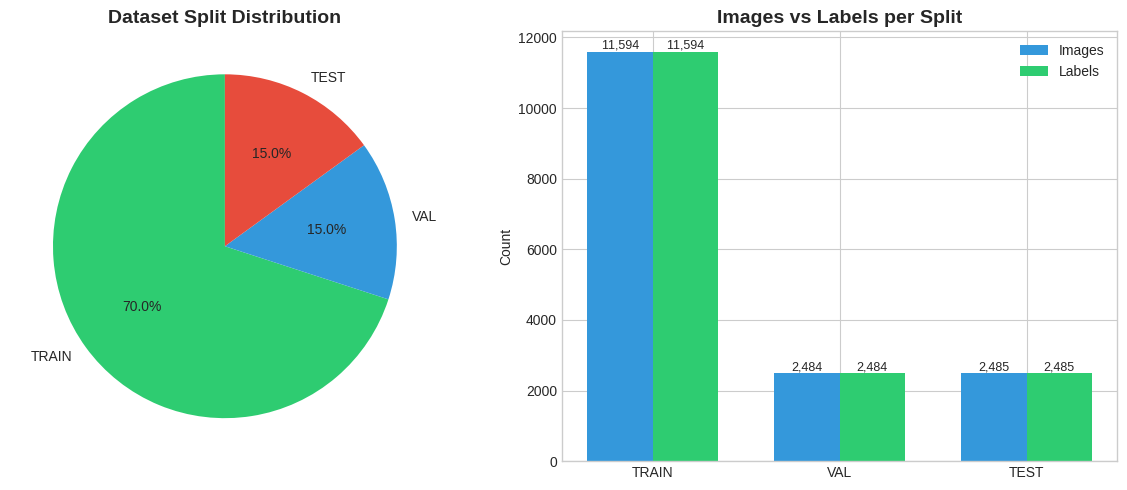

In [7]:
# Biểu đồ split distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

splits = list(splits_info.keys())
img_counts = [splits_info[s]['images'] for s in splits]
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].pie(img_counts, labels=[s.upper() for s in splits],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')

x = np.arange(len(splits)); w = 0.35
b1 = axes[1].bar(x - w/2, img_counts, w, label='Images', color='#3498db')
b2 = axes[1].bar(x + w/2, [splits_info[s]['labels'] for s in splits], w, label='Labels', color='#2ecc71')
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.upper() for s in splits])
axes[1].set_title('Images vs Labels per Split', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,}',
                 ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/01_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Class Distribution & Imbalance Check

In [8]:
def get_class_id_from_label(label_path):
    """
    Đọc class_id đầu tiên từ file label YOLO.
    Format: class_id [cx cy w h [kp...]]
    Với bài toán Classification, label chỉ có class_id.
    """
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    return int(parts[0])
    except Exception:
        pass
    return None

def count_classes_in_split(labels_dir):
    counter = Counter()
    lbl_files = list(Path(labels_dir).glob('*.txt')) if Path(labels_dir).exists() else []
    for lf in tqdm(lbl_files, desc=f"Counting {Path(labels_dir).parent.name}/{Path(labels_dir).name}"):
        cid = get_class_id_from_label(lf)
        if cid is not None:
            counter[cid] += 1
    return counter

train_class_counts = count_classes_in_split(TRAIN_LABELS)
val_class_counts   = count_classes_in_split(VAL_LABELS)
test_class_counts  = count_classes_in_split(TEST_LABELS)

print("\n📊 Class counts (TRAIN):")
for cid, cnt in sorted(train_class_counts.items()):
    name = class_names.get(cid, f'Class {cid}')
    print(f"  [{cid}] {name}: {cnt:,}")

Counting train/labels:   0%|          | 0/11594 [00:00<?, ?it/s]

Counting val/labels:   0%|          | 0/2484 [00:00<?, ?it/s]

Counting test/labels:   0%|          | 0/2485 [00:00<?, ?it/s]


📊 Class counts (TRAIN):
  [0] bench_pressing: 697
  [1] front_raises: 1,337
  [2] pull_ups: 756
  [3] push_up: 1,037
  [4] situp: 853
  [5] rope_pushdown: 868
  [6] deadlift: 3,963
  [9] squat: 2,051


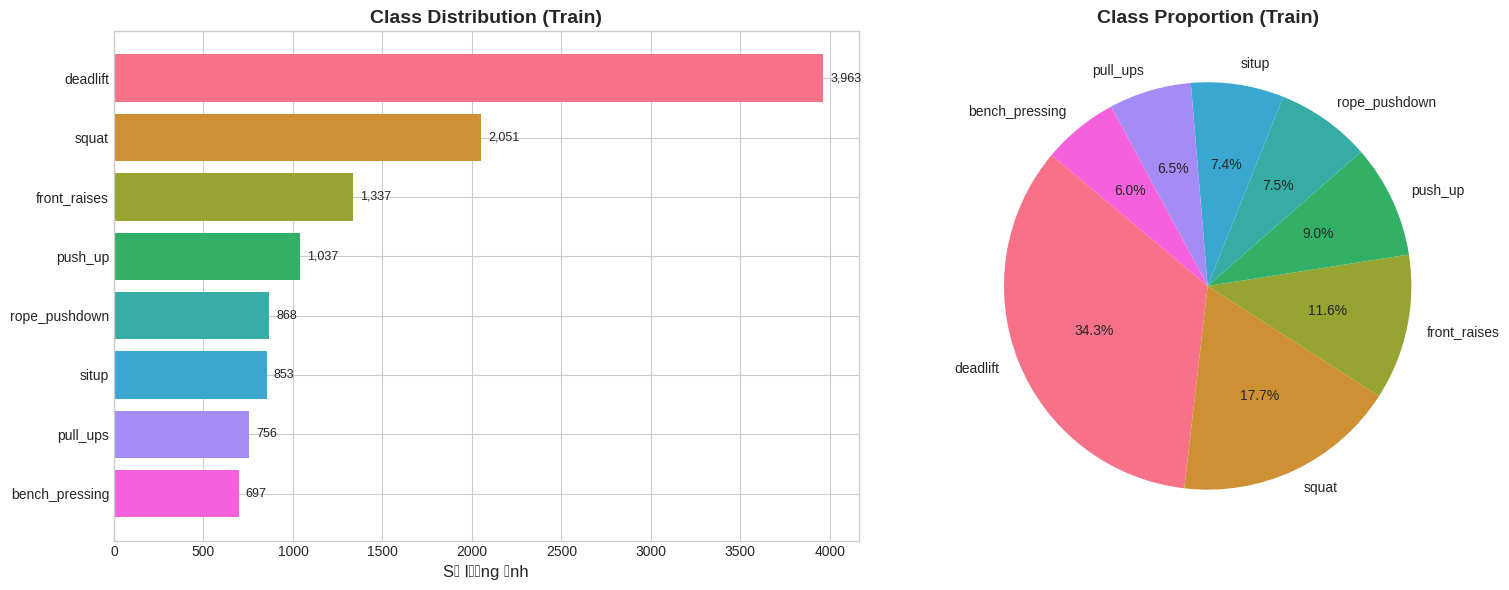

In [9]:
if train_class_counts:
    sorted_items = sorted(train_class_counts.items(), key=lambda x: x[1], reverse=True)
    cids   = [x[0] for x in sorted_items]
    counts = [x[1] for x in sorted_items]
    names  = [class_names.get(c, f'Class {c}') for c in cids]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Horizontal bar chart
    palette = sns.color_palette('husl', len(names))
    bars = axes[0].barh(names, counts, color=palette)
    axes[0].set_xlabel('Số lượng ảnh', fontsize=12)
    axes[0].set_title('Class Distribution (Train)', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    for bar, v in zip(bars, counts):
        axes[0].text(v + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{v:,}', va='center', fontsize=9)

    # Pie chart
    axes[1].pie(counts, labels=names, autopct='%1.1f%%',
                colors=palette, startangle=140)
    axes[1].set_title('Class Proportion (Train)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/kaggle/working/02_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Không tìm thấy label hợp lệ")

⚖️  IMBALANCE ANALYSIS (Train)
  Max : 3,963  (deadlift)
  Min : 697  (bench_pressing)
  Max/Min ratio : 5.69x
  Mean : 1445.2

🚨 Imbalance nặng (>5x) — cần xử lý: oversample / focal loss


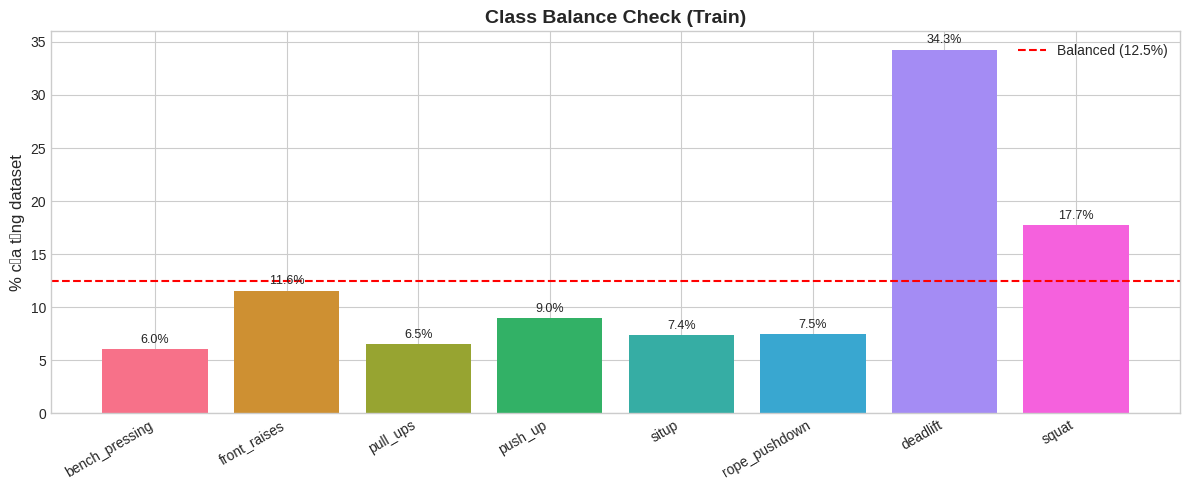

In [10]:
if train_class_counts:
    counts_arr = np.array(list(train_class_counts.values()), dtype=float)
    max_c  = counts_arr.max()
    min_c  = counts_arr.min()
    ratio  = max_c / min_c if min_c > 0 else float('inf')
    mean_c = counts_arr.mean()

    print("=" * 50)
    print("⚖️  IMBALANCE ANALYSIS (Train)")
    print("=" * 50)
    print(f"  Max : {int(max_c):,}  ({class_names.get(max(train_class_counts, key=train_class_counts.get), '?')})")
    print(f"  Min : {int(min_c):,}  ({class_names.get(min(train_class_counts, key=train_class_counts.get), '?')})")
    print(f"  Max/Min ratio : {ratio:.2f}x")
    print(f"  Mean : {mean_c:.1f}")

    if ratio < 2:
        print("\n✅ Dataset khá cân bằng (ratio < 2x)")
    elif ratio < 5:
        print("\n⚠️  Imbalance nhẹ (2-5x) — cân nhắc class_weight hoặc oversample")
    else:
        print("\n🚨 Imbalance nặng (>5x) — cần xử lý: oversample / focal loss")

    # Balance bar chart (% normalised)
    names_sorted  = [class_names.get(c, f'Class {c}') for c in sorted(train_class_counts)]
    counts_sorted = [train_class_counts[c] for c in sorted(train_class_counts)]
    normed = [c / sum(counts_sorted) * 100 for c in counts_sorted]

    fig, ax = plt.subplots(figsize=(12, 5))
    palette = sns.color_palette('husl', len(names_sorted))
    bars = ax.bar(names_sorted, normed, color=palette)
    ax.axhline(100 / len(normed), color='red', linestyle='--', linewidth=1.5,
               label=f'Balanced ({100/len(normed):.1f}%)')
    ax.set_ylabel('% của tổng dataset', fontsize=12)
    ax.set_title('Class Balance Check (Train)', fontsize=14, fontweight='bold')
    ax.set_xticklabels(names_sorted, rotation=30, ha='right')
    ax.legend()
    for bar, v in zip(bars, normed):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('/kaggle/working/03_imbalance_check.png', dpi=150, bbox_inches='tight')
    plt.show()

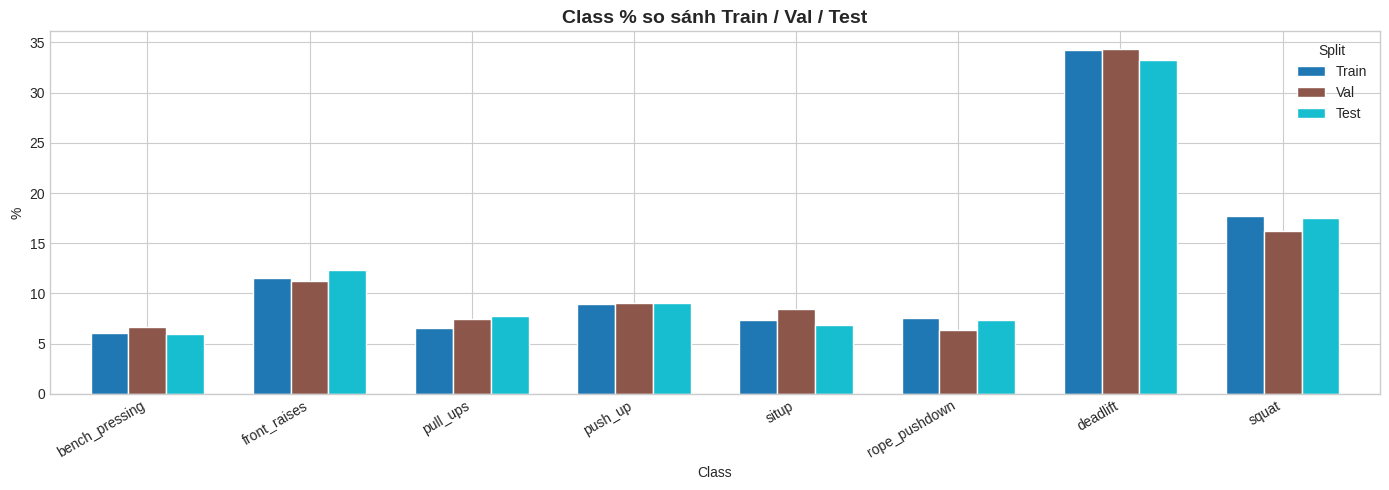

In [11]:
# So sánh class distribution giữa Train / Val / Test
all_cids = sorted(set(train_class_counts) | set(val_class_counts) | set(test_class_counts))
split_dicts = {'Train': train_class_counts, 'Val': val_class_counts, 'Test': test_class_counts}

df_dist = pd.DataFrame(
    {split: [d.get(c, 0) for c in all_cids] for split, d in split_dicts.items()},
    index=[class_names.get(c, f'Class {c}') for c in all_cids]
)
df_pct = df_dist.div(df_dist.sum(axis=0), axis=1) * 100

ax = df_pct.plot(kind='bar', figsize=(14, 5), colormap='tab10', edgecolor='white', width=0.7)
ax.set_title('Class % so sánh Train / Val / Test', fontsize=14, fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('Class')
ax.set_xticklabels(df_pct.index, rotation=30, ha='right')
ax.legend(title='Split')
plt.tight_layout()
plt.savefig('/kaggle/working/04_split_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Keypoints EDA

In [12]:
# ── Parse keypoints từ label YOLO Pose ───────────────────────────
# Format mỗi dòng: class_id cx cy w h [kp0_x kp0_y kp0_v ...]
# Nếu dataset chỉ có classification (class_id), keypoints = [] — OK.

def parse_label_line(line):
    parts = line.strip().split()
    if not parts:
        return None
    result = {'class_id': int(parts[0]), 'bbox': None, 'keypoints': []}
    if len(parts) >= 5:
        result['bbox'] = {
            'cx': float(parts[1]), 'cy': float(parts[2]),
            'w':  float(parts[3]), 'h':  float(parts[4])
        }
    kp_data = parts[5:]
    for i in range(0, len(kp_data) - 2, 3):
        result['keypoints'].append(
            (float(kp_data[i]), float(kp_data[i+1]), float(kp_data[i+2]))
        )
    return result

# Lấy mẫu tối đa 2000 file để EDA nhanh
MAX_SAMPLES = 2000
label_files_train = list(TRAIN_LABELS.glob('*.txt'))[:MAX_SAMPLES] if TRAIN_LABELS.exists() else []

all_kp_x, all_kp_y, all_kp_v = [], [], []
kp_counts, bbox_ws, bbox_hs = [], [], []
has_keypoints = False

for lf in tqdm(label_files_train, desc="Parsing labels"):
    with open(lf) as f:
        for line in f:
            ann = parse_label_line(line)
            if ann is None:
                continue
            if ann['bbox']:
                bbox_ws.append(ann['bbox']['w'])
                bbox_hs.append(ann['bbox']['h'])
            if ann['keypoints']:
                has_keypoints = True
                kp_counts.append(len(ann['keypoints']))
                for x, y, v in ann['keypoints']:
                    if v > 0:   # chỉ lấy keypoint visible
                        all_kp_x.append(x)
                        all_kp_y.append(y)
                        all_kp_v.append(v)

print(f"✅ Parsed {len(label_files_train):,} label files")
print(f"   Has keypoints : {has_keypoints}")
print(f"   Visible KPs   : {len(all_kp_x):,}")
print(f"   Has bbox info : {len(bbox_ws) > 0}")

Parsing labels:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ Parsed 2,000 label files
   Has keypoints : False
   Visible KPs   : 0
   Has bbox info : False


In [13]:
# ── Keypoints Heatmap ────────────────────────────────────────────
if has_keypoints and all_kp_x:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    h2d, xedge, yedge = np.histogram2d(all_kp_x, all_kp_y, bins=50, range=[[0,1],[0,1]])
    im = axes[0].imshow(h2d.T, origin='upper', aspect='auto',
                        extent=[0, 1, 1, 0], cmap='hot')
    plt.colorbar(im, ax=axes[0])
    axes[0].set_title('Keypoints Density Heatmap', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('x (normalized)'); axes[0].set_ylabel('y (normalized)')

    axes[1].hist(all_kp_x, bins=50, color='#3498db', edgecolor='white')
    axes[1].set_title('Keypoint X Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('x (normalized)'); axes[1].set_ylabel('Count')
    axes[1].axvline(np.mean(all_kp_x), color='red', ls='--',
                    label=f'mean={np.mean(all_kp_x):.2f}')
    axes[1].legend()

    axes[2].hist(all_kp_y, bins=50, color='#e74c3c', edgecolor='white')
    axes[2].set_title('Keypoint Y Distribution', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('y (normalized)'); axes[2].set_ylabel('Count')
    axes[2].axvline(np.mean(all_kp_y), color='blue', ls='--',
                    label=f'mean={np.mean(all_kp_y):.2f}')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/05_keypoints_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ℹ️  Dataset không có keypoints (classification only) — bỏ qua heatmap keypoints")

ℹ️  Dataset không có keypoints (classification only) — bỏ qua heatmap keypoints


In [14]:
# ── Số KP per annotation + Visibility ───────────────────────────
if has_keypoints and kp_counts:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(kp_counts, bins=range(min(kp_counts), max(kp_counts)+2),
                 color='#9b59b6', edgecolor='white')
    axes[0].set_title('Số Keypoints mỗi Annotation', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Số keypoints'); axes[0].set_ylabel('Frequency')
    axes[0].axvline(np.mean(kp_counts), color='red', ls='--',
                    label=f'mean={np.mean(kp_counts):.1f}')
    axes[0].legend()

    vis_counts = Counter(round(v) for v in all_kp_v)
    vis_labels = {0: 'Not labeled', 1: 'Occluded', 2: 'Visible'}
    vl = [vis_labels.get(k, str(k)) for k in sorted(vis_counts)]
    vc = [vis_counts[k] for k in sorted(vis_counts)]
    bar_colors = ['#e74c3c', '#f39c12', '#2ecc71'][:len(vl)]
    axes[1].bar(vl, vc, color=bar_colors)
    axes[1].set_title('Keypoint Visibility Stats', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(vc):
        axes[1].text(i, v + max(vc)*0.01, f'{v:,}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('/kaggle/working/06_keypoints_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# ── Bounding Box Analysis ────────────────────────────────────────
if bbox_ws:
    bbox_areas  = [w * h for w, h in zip(bbox_ws, bbox_hs)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(bbox_ws, bins=50, color='#1abc9c', edgecolor='white')
    axes[0].set_title('BBox Width (normalized)', fontweight='bold')
    axes[0].axvline(np.mean(bbox_ws), color='red', ls='--',
                    label=f'mean={np.mean(bbox_ws):.3f}')
    axes[0].legend()

    axes[1].hist(bbox_hs, bins=50, color='#e67e22', edgecolor='white')
    axes[1].set_title('BBox Height (normalized)', fontweight='bold')
    axes[1].axvline(np.mean(bbox_hs), color='red', ls='--',
                    label=f'mean={np.mean(bbox_hs):.3f}')
    axes[1].legend()

    axes[2].hist(bbox_areas, bins=50, color='#8e44ad', edgecolor='white')
    axes[2].set_title('BBox Area (w×h normalized)', fontweight='bold')
    axes[2].axvline(np.mean(bbox_areas), color='red', ls='--',
                    label=f'mean={np.mean(bbox_areas):.4f}')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/07_bbox_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ℹ️  Không có thông tin bounding box trong label")

ℹ️  Không có thông tin bounding box trong label


## 7️⃣ Sample Visualization (Ảnh + Class Label)

🖼️  Visualizing random training samples...


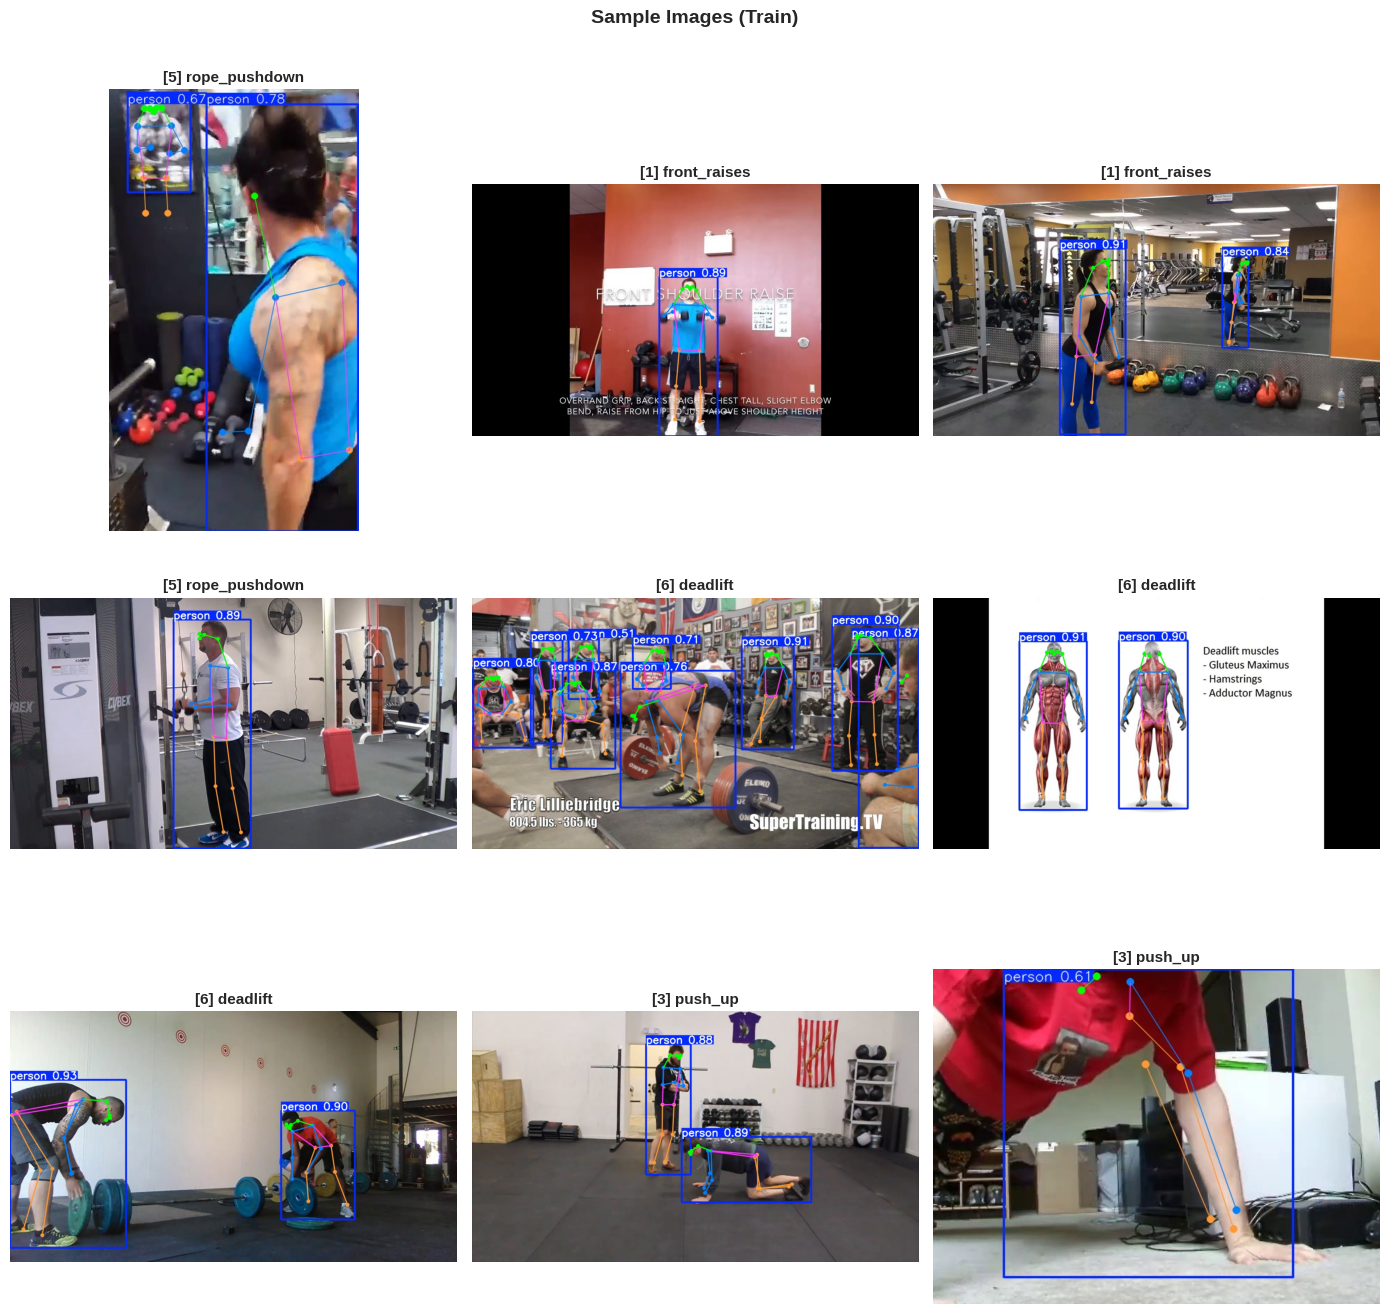

In [16]:
def show_sample_images(images_dir, labels_dir, n=9):
    """Hiển thị n ảnh ngẫu nhiên kèm class label."""
    img_files = (list(Path(images_dir).glob('*.jpg')) +
                 list(Path(images_dir).glob('*.png')))
    if not img_files:
        print("⚠️  Không tìm thấy ảnh")
        return
    samples = random.sample(img_files, min(n, len(img_files)))
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    axes = np.array(axes).flatten()

    for idx, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
        label_path = Path(labels_dir) / f"{img_path.stem}.txt"
        cid = get_class_id_from_label(label_path)
        cname = class_names.get(cid, f'Class {cid}') if cid is not None else 'No Label'
        axes[idx].set_title(f'[{cid}] {cname}', fontsize=11, fontweight='bold')
        axes[idx].axis('off')

    for i in range(len(samples), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Sample Images (Train)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/kaggle/working/08_sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

print("🖼️  Visualizing random training samples...")
show_sample_images(TRAIN_IMAGES, TRAIN_LABELS, n=9)

## 8️⃣ Data Quality Check

In [17]:
def check_data_quality(images_dir, labels_dir):
    """Kiểm tra thiếu label, thiếu ảnh, file rỗng."""
    images_dir, labels_dir = Path(images_dir), Path(labels_dir)
    issues = {
        'missing_labels' : [],
        'missing_images' : [],
        'empty_labels'   : [],
    }
    img_files  = (list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
                  if images_dir.exists() else [])
    lbl_files  = list(labels_dir.glob('*.txt')) if labels_dir.exists() else []
    img_stems  = {f.stem for f in img_files}
    lbl_stems  = {f.stem for f in lbl_files}

    for f in img_files:
        if f.stem not in lbl_stems:
            issues['missing_labels'].append(f.name)
    for f in lbl_files:
        if f.stem not in img_stems:
            issues['missing_images'].append(f.name)
        if f.stat().st_size == 0:
            issues['empty_labels'].append(f.name)
    return issues

print("🔍 Data Quality Check\n" + "=" * 50)
for split, (idir, ldir) in [('TRAIN', (TRAIN_IMAGES, TRAIN_LABELS)),
                              ('VAL',   (VAL_IMAGES,   VAL_LABELS)),
                              ('TEST',  (TEST_IMAGES,  TEST_LABELS))]:
    iss = check_data_quality(idir, ldir)
    ok  = all(len(v) == 0 for v in iss.values())
    print(f"\n{split}:")
    print(f"  Missing labels : {len(iss['missing_labels'])}")
    print(f"  Missing images : {len(iss['missing_images'])}")
    print(f"  Empty labels   : {len(iss['empty_labels'])}")
    print(f"  {'✅ No issues' if ok else '⚠️  Has issues — kiểm tra lại dữ liệu'}")

🔍 Data Quality Check

TRAIN:
  Missing labels : 0
  Missing images : 0
  Empty labels   : 32
  ⚠️  Has issues — kiểm tra lại dữ liệu

VAL:
  Missing labels : 0
  Missing images : 0
  Empty labels   : 0
  ✅ No issues

TEST:
  Missing labels : 0
  Missing images : 0
  Empty labels   : 0
  ✅ No issues


## 9️⃣ EDA Summary Report

In [18]:
print("=" * 60)
print("📊 EDA SUMMARY REPORT")
print("=" * 60)

print(f"""
📁 DATASET OVERVIEW
-------------------
Total Images : {total_images:,}
Total Labels : {total_labels:,}
  - Train    : {splits_info['train']['images']:,}
  - Val      : {splits_info['val']['images']:,}
  - Test     : {splits_info['test']['images']:,}

🏷️  CLASSES ({len(class_names)} classes)
-----------""")
for cid, cnt in sorted(train_class_counts.items()):
    print(f"  [{cid}] {class_names.get(cid, f'Class {cid}'):25s} : {cnt:,} samples")

if train_class_counts:
    vals  = list(train_class_counts.values())
    ratio = max(vals) / min(vals) if min(vals) > 0 else float('inf')
    if ratio < 2:
        status = "✅ Balanced"
    elif ratio < 5:
        status = "⚠️  Mild imbalance"
    else:
        status = "🚨 Severe imbalance"
    print(f"""
⚖️  IMBALANCE
------------
  Max/Min ratio : {ratio:.2f}x
  Status        : {status}
""")

print(f"""🔑 KEYPOINTS
-----------
  Has keypoints : {has_keypoints}
  Visible KPs   : {len(all_kp_x):,}

📁 Output files
---------------
  /kaggle/working/01_split_distribution.png
  /kaggle/working/02_class_distribution.png
  /kaggle/working/03_imbalance_check.png
  /kaggle/working/04_split_class_comparison.png
  /kaggle/working/05_keypoints_distribution.png  (nếu có KP)
  /kaggle/working/06_keypoints_stats.png          (nếu có KP)
  /kaggle/working/07_bbox_analysis.png
  /kaggle/working/08_sample_images.png
""")
print("=" * 60)
print("✅ EDA hoàn tất! Ready for training.")
print("=" * 60)

📊 EDA SUMMARY REPORT

📁 DATASET OVERVIEW
-------------------
Total Images : 16,563
Total Labels : 16,563
  - Train    : 11,594
  - Val      : 2,484
  - Test     : 2,485

🏷️  CLASSES (10 classes)
-----------
  [0] bench_pressing            : 697 samples
  [1] front_raises              : 1,337 samples
  [2] pull_ups                  : 756 samples
  [3] push_up                   : 1,037 samples
  [4] situp                     : 853 samples
  [5] rope_pushdown             : 868 samples
  [6] deadlift                  : 3,963 samples
  [9] squat                     : 2,051 samples

⚖️  IMBALANCE
------------
  Max/Min ratio : 5.69x
  Status        : 🚨 Severe imbalance

🔑 KEYPOINTS
-----------
  Has keypoints : False
  Visible KPs   : 0

📁 Output files
---------------
  /kaggle/working/01_split_distribution.png
  /kaggle/working/02_class_distribution.png
  /kaggle/working/03_imbalance_check.png
  /kaggle/working/04_split_class_comparison.png
  /kaggle/working/05_keypoints_distribution.png  (